# Мультимодальное распознавание эмоций (MER)

Пайплайн: **Видео → детекция лиц (MediaPipe) → CNN backbone → темпоральная агрегация → классификация эмоции**

Сравниваются **два backbone** × **три темпоральных агрегатора** = **6 моделей** на датасете **RAVDESS** (full-AV видео, 8 эмоций, 24 актёра):

| # | Backbone | Агрегация |
|---|---|---|
| 1–3 | MobileNetV3-Small (dim=576, ~3.6 MB) | Attention Pooling / BiLSTM / Transformer |
| 4–6 | EfficientNet-B0 (dim=1280, ~20 MB) | Attention Pooling / BiLSTM / Transformer |

Метрики: **Качество** (Accuracy, F1 macro) · **Скорость инференса** · **Размер пайплайна**

In [21]:
import os, io, time, gc, warnings
warnings.filterwarnings("ignore")

import cv2
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import torchvision.models as models
import torchvision.transforms as T

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report,
)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

SR = 16_000
N_MELS, MAX_LEN, HOP = 64, 128, 512
IMG_SIZE = 224
N_FRAMES = 8
results = []

EMOTION_MAP = {
    1: "neutral", 2: "calm", 3: "happy", 4: "sad",
    5: "angry", 6: "fearful", 7: "disgust", 8: "surprised",
}
N_CLASSES = len(EMOTION_MAP)


def pytorch_size_mb(model):
    b = sum(p.numel() * p.element_size() for p in model.parameters())
    b += sum(x.numel() * x.element_size() for x in model.buffers())
    return b / 1024 ** 2

Device: mps


## 1. Загрузка видео-данных RAVDESS

In [22]:
RAVDESS_PATH = "../datasets/orvile/ravdess-dataset/versions/1/"

video_paths, emo_labels, actor_ids = [], [], []

for d in sorted(os.listdir(RAVDESS_PATH)):
    if not d.startswith("Video_Speech_Actor_"):
        continue
    actor_dir = os.path.join(RAVDESS_PATH, d)
    for actor_sub in sorted(os.listdir(actor_dir)):
        if not actor_sub.startswith("Actor_"):
            continue
        actor_path = os.path.join(actor_dir, actor_sub)
        for f in sorted(os.listdir(actor_path)):
            if not f.endswith(".mp4"):
                continue
            parts = f.replace(".mp4", "").split("-")
            modality = int(parts[0])
            if modality != 1:
                continue
            emotion = int(parts[2])
            actor = int(parts[6])
            video_paths.append(os.path.join(actor_path, f))
            emo_labels.append(emotion - 1)
            actor_ids.append(actor)

emo_labels = np.array(emo_labels)
actor_ids = np.array(actor_ids)

unique_actors = sorted(set(actor_ids))
n_test_actors = max(1, len(unique_actors) // 5)
test_actors = set(unique_actors[-n_test_actors:])

train_idx = [i for i, a in enumerate(actor_ids) if a not in test_actors]
test_idx  = [i for i, a in enumerate(actor_ids) if a in test_actors]

train_videos = [video_paths[i] for i in train_idx]
test_videos  = [video_paths[i] for i in test_idx]
y_train = emo_labels[train_idx]
y_test  = emo_labels[test_idx]

print(f"Всего видео (full-AV speech): {len(video_paths)}")
for emo_id, name in EMOTION_MAP.items():
    print(f"  {name}: {(emo_labels == emo_id - 1).sum()}")
print(f"\nSpeaker-independent split (20 % актёров → test):")
print(f"  Train: {len(train_videos)} видео ({len(unique_actors) - n_test_actors} актёров)")
print(f"  Test:  {len(test_videos)} видео ({n_test_actors} актёров)")

Всего видео (full-AV speech): 1440
  neutral: 96
  calm: 192
  happy: 192
  sad: 192
  angry: 192
  fearful: 192
  disgust: 192
  surprised: 192

Speaker-independent split (20 % актёров → test):
  Train: 1200 видео (20 актёров)
  Test:  240 видео (4 актёров)


## 2. Предобработка: детекция лиц и извлечение признаков

**Стадия 1** — MediaPipe FaceDetector (`blaze_face_short_range`): обнаружение bounding box лица → обрезка → resize до 224×224  
**Стадия 2** — два backbone сравниваются:
- **MobileNetV3-Small** (dim=576, ~3.6 MB) — лёгкий мобильный backbone
- **EfficientNet-B0** (dim=1280, ~20 MB) — точный backbone с compound scaling

In [23]:
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

_DETECTOR_PATH = "../raw_models/blaze_face_short_range.tflite"
_face_detector = mp_vision.FaceDetector.create_from_options(
    mp_vision.FaceDetectorOptions(
        base_options=mp_python.BaseOptions(model_asset_path=_DETECTOR_PATH),
        min_detection_confidence=0.5,
    )
)

imagenet_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def extract_frames(video_path, n_frames=8):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return []
    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames


def detect_and_crop_face(frame, target_size=IMG_SIZE):
    """MediaPipe FaceDetector → bbox crop → resize. Falls back to center crop."""
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
    result = _face_detector.detect(mp_img)
    if result.detections:
        bb = result.detections[0].bounding_box
        h, w = frame.shape[:2]
        pad_x = int(bb.width * 0.1)
        pad_y = int(bb.height * 0.1)
        x1 = max(0, bb.origin_x - pad_x)
        y1 = max(0, bb.origin_y - pad_y)
        x2 = min(w, bb.origin_x + bb.width + pad_x)
        y2 = min(h, bb.origin_y + bb.height + pad_y)
        if x2 > x1 and y2 > y1:
            return cv2.resize(frame[y1:y2, x1:x2], (target_size, target_size))
    h, w = frame.shape[:2]
    s = min(h, w)
    y1, x1 = (h - s) // 2, (w - s) // 2
    return cv2.resize(frame[y1:y1 + s, x1:x1 + s], (target_size, target_size))


def extract_face_crops(video_list, n_frames=N_FRAMES):
    """Stage 1: video → sampled frames → face detection → list of crops per video."""
    all_crops = []
    for vp in tqdm(video_list, desc="Face detection"):
        frames = extract_frames(vp, n_frames)
        if not frames:
            crops = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * n_frames
        else:
            while len(frames) < n_frames:
                frames.append(frames[-1])
            crops = [detect_and_crop_face(f) for f in frames[:n_frames]]
        all_crops.append(crops)
    return all_crops  # List[List[np.ndarray(H,W,3)]], len = n_videos


print("Утилиты загружены ✓")

Утилиты загружены ✓


I0000 00:00:1776536776.708392 21368955 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1776536776.709426 21368958 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [24]:
# ── Стадия 1: Детекция лиц → обрезка → resize 224×224 ────────────────────────
print("Стадия 1: Детекция лиц (MediaPipe)...")
train_crops = extract_face_crops(train_videos)
test_crops  = extract_face_crops(test_videos)
print(f"Train: {len(train_crops)} видео × {N_FRAMES} кропов")
print(f"Test:  {len(test_crops)} видео × {N_FRAMES} кропов")

# ── Стадия 2: MobileNetV3-Small → признаковые векторы ────────────────────────
mobilenet = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
FEAT_DIM = 576
mobilenet.classifier = nn.Identity()
mobilenet = mobilenet.to(device).eval()
mobilenet_mb = pytorch_size_mb(mobilenet)
print(f"\nСтадия 2: MobileNetV3-Small ({mobilenet_mb:.1f} MB, dim={FEAT_DIM})")


def extract_features(crops_list):
    """Stage 2: pre-cropped face images → MobileNetV3-Small feature vectors."""
    all_feats = []
    for crops in tqdm(crops_list, desc="MobileNet features"):
        faces = torch.stack([imagenet_transform(c) for c in crops])
        with torch.no_grad():
            feats = mobilenet(faces.to(device)).cpu()
        all_feats.append(feats)
    return torch.stack(all_feats)


train_vis = extract_features(train_crops)
test_vis  = extract_features(test_crops)
print(f"Train features: {train_vis.shape}  |  Test features: {test_vis.shape}")

# ── Стадия 2b: EfficientNet-B0 → признаковые векторы ─────────────────────────
efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
FEAT_DIM_EFF = 1280
efficientnet.classifier = nn.Identity()
efficientnet = efficientnet.to(device).eval()
efficientnet_mb = pytorch_size_mb(efficientnet)
print(f"\nСтадия 2b: EfficientNet-B0 ({efficientnet_mb:.1f} MB, dim={FEAT_DIM_EFF})")


def extract_features_efficientnet(crops_list):
    """Stage 2b: pre-cropped face images → EfficientNet-B0 feature vectors."""
    all_feats = []
    for crops in tqdm(crops_list, desc="EfficientNet features"):
        faces = torch.stack([imagenet_transform(c) for c in crops])
        with torch.no_grad():
            feats = efficientnet(faces.to(device)).cpu()
        all_feats.append(feats)
    return torch.stack(all_feats)


train_vis_eff = extract_features_efficientnet(train_crops)
test_vis_eff = extract_features_efficientnet(test_crops)
print(f"Train (EfficientNet): {train_vis_eff.shape}  |  Test (EfficientNet): {test_vis_eff.shape}")

Стадия 1: Детекция лиц (MediaPipe)...


Face detection: 100%|██████████| 240/240 [00:27<00:00,  8.59it/s]


Train: 1200 видео × 8 кропов
Test:  240 видео × 8 кропов

Стадия 2: MobileNetV3-Small (3.6 MB, dim=576)


MobileNet features: 100%|██████████| 240/240 [00:03<00:00, 69.83it/s]


Train features: torch.Size([1200, 8, 576])  |  Test features: torch.Size([240, 8, 576])
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/kaparya/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:02<00:00, 7.82MB/s]



Стадия 2b: EfficientNet-B0 (15.4 MB, dim=1280)


EfficientNet features: 100%|██████████| 240/240 [00:06<00:00, 39.94it/s]

Train (EfficientNet): torch.Size([1200, 8, 1280])  |  Test (EfficientNet): torch.Size([240, 8, 1280])


## 3. Наш подход: MobileNetV3-Small + Attention Pooling

8 кадров → детекция лиц (MediaPipe) → MobileNetV3-Small признаки → обучаемый **Attention Pooling** → FC-классификатор

Attention-веса вычисляются из самих признаков (score = Tanh(W·f)), что позволяет модели
автоматически фокусироваться на наиболее информативных кадрах.

In [28]:
from calendar import EPOCH


class AttentionPoolingClassifier(nn.Module):
    def __init__(self, feat_dim=1280, n_classes=8, hidden=128):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(feat_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x):
        # x: (batch, n_frames, feat_dim)
        attn_weights = self.attention(x)           # (batch, n_frames, 1)
        attn_weights = torch.softmax(attn_weights, dim=1)
        pooled = (attn_weights * x).sum(dim=1)     # (batch, feat_dim)
        return self.classifier(pooled)


model_1 = AttentionPoolingClassifier(FEAT_DIM, N_CLASSES).to(device)
opt1 = optim.Adam(model_1.parameters(), lr=1e-3, weight_decay=5e-4)
crit = nn.CrossEntropyLoss(label_smoothing=0.1)

ds1 = TensorDataset(train_vis, torch.tensor(y_train, dtype=torch.long))
loader1 = DataLoader(ds1, batch_size=32, shuffle=True)

EPOCHS = 60
t0 = time.time()
for ep in range(EPOCHS):
    model_1.train()
    for xb, yb in loader1:
        xb, yb = xb.to(device), yb.to(device)
        xb = xb + 0.05 * torch.randn_like(xb)  # feature-space augmentation
        loss = crit(model_1(xb), yb)
        opt1.zero_grad(); loss.backward(); opt1.step()
    if (ep + 1) % 10 == 0:
        model_1.eval()
        with torch.no_grad():
            acc = (model_1(train_vis.to(device)).argmax(1).cpu().numpy() == y_train).mean()
        print(f"Epoch {ep+1}/{EPOCHS} | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_1 = time.time() - t0

# Инференс: полный пайплайн (видео → эмоция)
model_1.eval()
t0 = time.time()
preds_1 = []
for vp in tqdm(test_videos):
    frames = extract_frames(vp, N_FRAMES)
    if not frames:
        crops = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    else:
        while len(frames) < N_FRAMES:
            frames.append(frames[-1])
        crops = [detect_and_crop_face(f) for f in frames[:N_FRAMES]]
    faces = torch.stack([imagenet_transform(c) for c in crops])
    with torch.no_grad():
        feats = mobilenet(faces.to(device)).unsqueeze(0)
        preds_1.append(model_1(feats).argmax(1).item())
inf_time_1 = (time.time() - t0) / len(test_videos)
preds_1 = np.array(preds_1)

cls_1_mb = pytorch_size_mb(model_1)
pipe_1_mb = mobilenet_mb + cls_1_mb

results.append({
    "Модель": "MobileNet + Attention",
    "Accuracy": accuracy_score(y_test, preds_1),
    "F1 (macro)": f1_score(y_test, preds_1, average="macro"),
    "Precision": precision_score(y_test, preds_1, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_1, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_1 * 1000,
    "Обучение (сек)": train_time_1,
    "Классификатор (MB)": cls_1_mb,
    "Пайплайн (MB)": pipe_1_mb,
})
print(f"\nMobileNet + Attention → Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_1*1000:.1f} мс/файл  Pipeline={pipe_1_mb:.1f} MB")

Epoch 10/60 | Loss 1.6766 | Train Acc 0.5917
Epoch 20/60 | Loss 1.1578 | Train Acc 0.7408
Epoch 30/60 | Loss 1.0759 | Train Acc 0.7992
Epoch 40/60 | Loss 0.9544 | Train Acc 0.8608
Epoch 50/60 | Loss 0.9922 | Train Acc 0.8975
Epoch 60/60 | Loss 0.8818 | Train Acc 0.9225


100%|██████████| 240/240 [00:32<00:00,  7.43it/s]


MobileNet + Attention → Acc=0.4208 F1=0.3889 Inf=134.7 мс/файл  Pipeline=4.0 MB


## 4. Базовая линия: MobileNetV3-Small + BiLSTM

8 кадров → детекция лиц (MediaPipe) → MobileNetV3-Small признаки → **Двунаправленный LSTM** → FC-классификатор

Конкатенация финальных скрытых состояний прямого и обратного проходов
даёт признаковый вектор размера `2 × hidden`, который подаётся в классификатор.

In [29]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, feat_dim=1280, hidden=128, n_classes=8):
        super().__init__()
        self.bilstm = nn.LSTM(
            feat_dim, hidden, batch_first=True, bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        # x: (batch, n_frames, feat_dim)
        _, (h, _) = self.bilstm(x)
        h = torch.cat([h[0], h[1]], dim=1)  # (batch, hidden*2)
        return self.classifier(h)


model_2 = BiLSTMClassifier(FEAT_DIM, hidden=128, n_classes=N_CLASSES).to(device)
opt2 = optim.Adam(model_2.parameters(), lr=1e-3, weight_decay=5e-4)

ds2 = TensorDataset(train_vis, torch.tensor(y_train, dtype=torch.long))
loader2 = DataLoader(ds2, batch_size=32, shuffle=True)

t0 = time.time()
for ep in range(30):
    model_2.train()
    for xb, yb in loader2:
        xb, yb = xb.to(device), yb.to(device)
        xb = xb + 0.05 * torch.randn_like(xb)  # feature-space augmentation
        loss = crit(model_2(xb), yb)
        opt2.zero_grad(); loss.backward(); opt2.step()
    if (ep + 1) % 10 == 0:
        model_2.eval()
        with torch.no_grad():
            acc = (model_2(train_vis.to(device)).argmax(1).cpu().numpy() == y_train).mean()
        print(f"Epoch {ep+1}/30 | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_2 = time.time() - t0

# Инференс: полный пайплайн (видео → эмоция)
model_2.eval()
t0 = time.time()
preds_2 = []
for vp in tqdm(test_videos):
    frames = extract_frames(vp, N_FRAMES)
    if not frames:
        crops = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    else:
        while len(frames) < N_FRAMES:
            frames.append(frames[-1])
        crops = [detect_and_crop_face(f) for f in frames[:N_FRAMES]]
    faces = torch.stack([imagenet_transform(c) for c in crops])
    with torch.no_grad():
        feats = mobilenet(faces.to(device)).unsqueeze(0)
        preds_2.append(model_2(feats).argmax(1).item())
inf_time_2 = (time.time() - t0) / len(test_videos)
preds_2 = np.array(preds_2)

cls_2_mb = pytorch_size_mb(model_2)
pipe_2_mb = mobilenet_mb + cls_2_mb

results.append({
    "Модель": "MobileNet + BiLSTM",
    "Accuracy": accuracy_score(y_test, preds_2),
    "F1 (macro)": f1_score(y_test, preds_2, average="macro"),
    "Precision": precision_score(y_test, preds_2, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_2, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_2 * 1000,
    "Обучение (сек)": train_time_2,
    "Классификатор (MB)": cls_2_mb,
    "Пайплайн (MB)": pipe_2_mb,
})
print(f"\nMobileNet + BiLSTM → Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_2*1000:.1f} мс/файл  Pipeline={pipe_2_mb:.1f} MB")

Epoch 10/30 | Loss 1.4002 | Train Acc 0.6908
Epoch 20/30 | Loss 0.9382 | Train Acc 0.8117
Epoch 30/30 | Loss 0.7303 | Train Acc 0.9450


100%|██████████| 240/240 [00:33<00:00,  7.20it/s]


MobileNet + BiLSTM → Acc=0.3792 F1=0.3330 Inf=138.9 мс/файл  Pipeline=6.4 MB


## 5. Сильная модель: MobileNetV3-Small + Transformer

8 кадров → детекция лиц (MediaPipe) → MobileNetV3-Small признаки → **Transformer Encoder** → Global Average Pooling → FC-классификатор

Self-attention механизм позволяет каждому кадру «обращать внимание» на все остальные кадры,
что обеспечивает глобальный контекст по всей последовательности.

In [30]:
class TransformerClassifier(nn.Module):
    def __init__(self, feat_dim=1280, n_heads=4, n_layers=1, n_classes=8, dropout=0.4):
        super().__init__()
        self.proj = nn.Linear(feat_dim, 256)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256, nhead=n_heads, dim_feedforward=512,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        # x: (batch, n_frames, feat_dim)
        x = self.proj(x)                       # (batch, n_frames, 256)
        x = self.transformer(x)                # (batch, n_frames, 256)
        x = x.mean(dim=1)                      # global average pooling
        return self.classifier(x)


model_3 = TransformerClassifier(FEAT_DIM, n_heads=4, n_layers=1, n_classes=N_CLASSES).to(device)
opt3 = optim.Adam(model_3.parameters(), lr=3e-4, weight_decay=2e-3)

ds3 = TensorDataset(train_vis, torch.tensor(y_train, dtype=torch.long))
loader3 = DataLoader(ds3, batch_size=32, shuffle=True)
scheduler3 = torch.optim.lr_scheduler.OneCycleLR(
    opt3, max_lr=3e-4, steps_per_epoch=len(loader3), epochs=20, pct_start=0.2
)

t0 = time.time()
for ep in range(20):
    model_3.train()
    for xb, yb in loader3:
        xb, yb = xb.to(device), yb.to(device)
        xb = xb + 0.1 * torch.randn_like(xb)  # feature-space augmentation
        loss = crit(model_3(xb), yb)
        opt3.zero_grad(); loss.backward(); opt3.step()
        scheduler3.step()
    if (ep + 1) % 5 == 0:
        model_3.eval()
        with torch.no_grad():
            acc = (model_3(train_vis.to(device)).argmax(1).cpu().numpy() == y_train).mean()
        print(f"Epoch {ep+1}/20 | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_3 = time.time() - t0

# Инференс: полный пайплайн (видео → эмоция)
model_3.eval()
t0 = time.time()
preds_3 = []
for vp in tqdm(test_videos):
    frames = extract_frames(vp, N_FRAMES)
    if not frames:
        crops = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    else:
        while len(frames) < N_FRAMES:
            frames.append(frames[-1])
        crops = [detect_and_crop_face(f) for f in frames[:N_FRAMES]]
    faces = torch.stack([imagenet_transform(c) for c in crops])
    with torch.no_grad():
        feats = mobilenet(faces.to(device)).unsqueeze(0)
        preds_3.append(model_3(feats).argmax(1).item())
inf_time_3 = (time.time() - t0) / len(test_videos)
preds_3 = np.array(preds_3)

cls_3_mb = pytorch_size_mb(model_3)
pipe_3_mb = mobilenet_mb + cls_3_mb

results.append({
    "Модель": "MobileNet + Transformer",
    "Accuracy": accuracy_score(y_test, preds_3),
    "F1 (macro)": f1_score(y_test, preds_3, average="macro"),
    "Precision": precision_score(y_test, preds_3, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_3, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_3 * 1000,
    "Обучение (сек)": train_time_3,
    "Классификатор (MB)": cls_3_mb,
    "Пайплайн (MB)": pipe_3_mb,
})
print(f"\nMobileNet + Transformer → Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_3*1000:.1f} мс/файл  Pipeline={pipe_3_mb:.1f} MB")

Epoch 5/20 | Loss 1.5698 | Train Acc 0.3508
Epoch 10/20 | Loss 1.0908 | Train Acc 0.7425
Epoch 15/20 | Loss 0.7963 | Train Acc 0.8575
Epoch 20/20 | Loss 0.8938 | Train Acc 0.8850


100%|██████████| 240/240 [00:31<00:00,  7.61it/s]


MobileNet + Transformer → Acc=0.3625 F1=0.3408 Inf=131.4 мс/файл  Pipeline=6.3 MB


## 6. EfficientNet-B0 + Attention Pooling

8 кадров → детекция лиц (MediaPipe) → **EfficientNet-B0** признаки → **Attention Pooling** → FC-классификатор

Та же темпоральная схема, что и для MobileNet, но с более ёмким backbone (dim=1280).

In [31]:
model_4 = AttentionPoolingClassifier(FEAT_DIM_EFF, N_CLASSES).to(device)
opt4 = optim.Adam(model_4.parameters(), lr=1e-3, weight_decay=5e-4)

ds4 = TensorDataset(train_vis_eff, torch.tensor(y_train, dtype=torch.long))
loader4 = DataLoader(ds4, batch_size=32, shuffle=True)

t0 = time.time()
for ep in range(30):
    model_4.train()
    for xb, yb in loader4:
        xb, yb = xb.to(device), yb.to(device)
        xb = xb + 0.05 * torch.randn_like(xb)
        loss = crit(model_4(xb), yb)
        opt4.zero_grad(); loss.backward(); opt4.step()
    if (ep + 1) % 10 == 0:
        model_4.eval()
        with torch.no_grad():
            acc = (model_4(train_vis_eff.to(device)).argmax(1).cpu().numpy() == y_train).mean()
        print(f"Epoch {ep+1}/30 | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_4 = time.time() - t0

model_4.eval()
t0 = time.time()
preds_4 = []
for vp in tqdm(test_videos):
    frames = extract_frames(vp, N_FRAMES)
    if not frames:
        crops = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    else:
        while len(frames) < N_FRAMES:
            frames.append(frames[-1])
        crops = [detect_and_crop_face(f) for f in frames[:N_FRAMES]]
    faces = torch.stack([imagenet_transform(c) for c in crops])
    with torch.no_grad():
        feats = efficientnet(faces.to(device)).unsqueeze(0)
        preds_4.append(model_4(feats).argmax(1).item())
inf_time_4 = (time.time() - t0) / len(test_videos)
preds_4 = np.array(preds_4)

cls_4_mb = pytorch_size_mb(model_4)
pipe_4_mb = efficientnet_mb + cls_4_mb

results.append({
    "Модель": "EfficientNet + Attention",
    "Accuracy": accuracy_score(y_test, preds_4),
    "F1 (macro)": f1_score(y_test, preds_4, average="macro"),
    "Precision": precision_score(y_test, preds_4, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_4, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_4 * 1000,
    "Обучение (сек)": train_time_4,
    "Классификатор (MB)": cls_4_mb,
    "Пайплайн (MB)": pipe_4_mb,
})
print(f"\nEfficientNet + Attention → Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_4*1000:.1f} мс/файл  Pipeline={pipe_4_mb:.1f} MB")

Epoch 10/30 | Loss 0.9910 | Train Acc 0.8025
Epoch 20/30 | Loss 1.1753 | Train Acc 0.8525
Epoch 30/30 | Loss 1.1059 | Train Acc 0.9508


100%|██████████| 240/240 [00:35<00:00,  6.67it/s]


EfficientNet + Attention → Acc=0.3417 F1=0.2826 Inf=149.9 мс/файл  Pipeline=16.4 MB


## 7. EfficientNet-B0 + BiLSTM

8 кадров → детекция лиц (MediaPipe) → EfficientNet-B0 признаки → **BiLSTM** → FC-классификатор

In [32]:
model_5 = BiLSTMClassifier(FEAT_DIM_EFF, hidden=128, n_classes=N_CLASSES).to(device)
opt5 = optim.Adam(model_5.parameters(), lr=1e-3, weight_decay=5e-4)

ds5 = TensorDataset(train_vis_eff, torch.tensor(y_train, dtype=torch.long))
loader5 = DataLoader(ds5, batch_size=32, shuffle=True)

t0 = time.time()
for ep in range(30):
    model_5.train()
    for xb, yb in loader5:
        xb, yb = xb.to(device), yb.to(device)
        xb = xb + 0.05 * torch.randn_like(xb)
        loss = crit(model_5(xb), yb)
        opt5.zero_grad(); loss.backward(); opt5.step()
    if (ep + 1) % 10 == 0:
        model_5.eval()
        with torch.no_grad():
            acc = (model_5(train_vis_eff.to(device)).argmax(1).cpu().numpy() == y_train).mean()
        print(f"Epoch {ep+1}/30 | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_5 = time.time() - t0

model_5.eval()
t0 = time.time()
preds_5 = []
for vp in tqdm(test_videos):
    frames = extract_frames(vp, N_FRAMES)
    if not frames:
        crops = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    else:
        while len(frames) < N_FRAMES:
            frames.append(frames[-1])
        crops = [detect_and_crop_face(f) for f in frames[:N_FRAMES]]
    faces = torch.stack([imagenet_transform(c) for c in crops])
    with torch.no_grad():
        feats = efficientnet(faces.to(device)).unsqueeze(0)
        preds_5.append(model_5(feats).argmax(1).item())
inf_time_5 = (time.time() - t0) / len(test_videos)
preds_5 = np.array(preds_5)

cls_5_mb = pytorch_size_mb(model_5)
pipe_5_mb = efficientnet_mb + cls_5_mb

results.append({
    "Модель": "EfficientNet + BiLSTM",
    "Accuracy": accuracy_score(y_test, preds_5),
    "F1 (macro)": f1_score(y_test, preds_5, average="macro"),
    "Precision": precision_score(y_test, preds_5, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_5, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_5 * 1000,
    "Обучение (сек)": train_time_5,
    "Классификатор (MB)": cls_5_mb,
    "Пайплайн (MB)": pipe_5_mb,
})
print(f"\nEfficientNet + BiLSTM → Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_5*1000:.1f} мс/файл  Pipeline={pipe_5_mb:.1f} MB")

Epoch 10/30 | Loss 1.1332 | Train Acc 0.8108
Epoch 20/30 | Loss 0.9183 | Train Acc 0.9508
Epoch 30/30 | Loss 0.7599 | Train Acc 0.9800


100%|██████████| 240/240 [00:34<00:00,  7.01it/s]


EfficientNet + BiLSTM → Acc=0.3708 F1=0.3343 Inf=142.6 мс/файл  Pipeline=21.0 MB


## 8. EfficientNet-B0 + Transformer

8 кадров → детекция лиц (MediaPipe) → EfficientNet-B0 признаки → **Transformer Encoder** → Global Average Pooling → FC-классификатор

In [33]:
model_6 = TransformerClassifier(FEAT_DIM_EFF, n_heads=4, n_layers=1, n_classes=N_CLASSES).to(device)
opt6 = optim.Adam(model_6.parameters(), lr=3e-4, weight_decay=2e-3)

ds6 = TensorDataset(train_vis_eff, torch.tensor(y_train, dtype=torch.long))
loader6 = DataLoader(ds6, batch_size=32, shuffle=True)
scheduler6 = torch.optim.lr_scheduler.OneCycleLR(
    opt6, max_lr=3e-4, steps_per_epoch=len(loader6), epochs=20, pct_start=0.2
)

t0 = time.time()
for ep in range(20):
    model_6.train()
    for xb, yb in loader6:
        xb, yb = xb.to(device), yb.to(device)
        xb = xb + 0.1 * torch.randn_like(xb)
        loss = crit(model_6(xb), yb)
        opt6.zero_grad(); loss.backward(); opt6.step()
        scheduler6.step()
    if (ep + 1) % 5 == 0:
        model_6.eval()
        with torch.no_grad():
            acc = (model_6(train_vis_eff.to(device)).argmax(1).cpu().numpy() == y_train).mean()
        print(f"Epoch {ep+1}/20 | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_6 = time.time() - t0

model_6.eval()
t0 = time.time()
preds_6 = []
for vp in tqdm(test_videos):
    frames = extract_frames(vp, N_FRAMES)
    if not frames:
        crops = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    else:
        while len(frames) < N_FRAMES:
            frames.append(frames[-1])
        crops = [detect_and_crop_face(f) for f in frames[:N_FRAMES]]
    faces = torch.stack([imagenet_transform(c) for c in crops])
    with torch.no_grad():
        feats = efficientnet(faces.to(device)).unsqueeze(0)
        preds_6.append(model_6(feats).argmax(1).item())
inf_time_6 = (time.time() - t0) / len(test_videos)
preds_6 = np.array(preds_6)

cls_6_mb = pytorch_size_mb(model_6)
pipe_6_mb = efficientnet_mb + cls_6_mb

results.append({
    "Модель": "EfficientNet + Transformer",
    "Accuracy": accuracy_score(y_test, preds_6),
    "F1 (macro)": f1_score(y_test, preds_6, average="macro"),
    "Precision": precision_score(y_test, preds_6, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_6, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_6 * 1000,
    "Обучение (сек)": train_time_6,
    "Классификатор (MB)": cls_6_mb,
    "Пайплайн (MB)": pipe_6_mb,
})
print(f"\nEfficientNet + Transformer → Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_6*1000:.1f} мс/файл  Pipeline={pipe_6_mb:.1f} MB")

Epoch 5/20 | Loss 1.2528 | Train Acc 0.6783
Epoch 10/20 | Loss 0.9236 | Train Acc 0.8542
Epoch 15/20 | Loss 0.7288 | Train Acc 0.9400
Epoch 20/20 | Loss 0.7473 | Train Acc 0.9575


100%|██████████| 240/240 [00:35<00:00,  6.72it/s]


EfficientNet + Transformer → Acc=0.4083 F1=0.3568 Inf=148.7 мс/файл  Pipeline=18.8 MB


## 10. Сводная таблица и визуализация

In [34]:
df = pd.DataFrame(results)

fmt = {
    "Accuracy": "{:.4f}", "F1 (macro)": "{:.4f}",
    "Precision": "{:.4f}", "Recall": "{:.4f}",
    "Инференс (мс/файл)": "{:.1f}",
    "Обучение (сек)": "{:.1f}",
    "Классификатор (MB)": "{:.3f}",
    "Пайплайн (MB)": "{:.2f}",
}
print(df.to_string(index=False, formatters={k: v.format for k, v in fmt.items()}))

emo_names = [EMOTION_MAP[i + 1] for i in range(N_CLASSES)]

all_preds = [preds_1, preds_2, preds_3, preds_4, preds_5, preds_6]
for name, preds in zip(df["Модель"], all_preds):
    print(f"\n{'=' * 60}")
    print(name)
    print(classification_report(y_test, preds, target_names=emo_names, zero_division=0))

                    Модель Accuracy F1 (macro) Precision Recall Инференс (мс/файл) Обучение (сек) Классификатор (MB) Пайплайн (MB)
     MobileNet + Attention   0.4208     0.3889    0.5479 0.4258              134.7           10.6              0.427          4.01
        MobileNet + BiLSTM   0.3792     0.3330    0.5828 0.3633              138.9            8.3              2.823          6.41
   MobileNet + Transformer   0.3625     0.3408    0.5150 0.3672              131.4            6.9              2.704          6.29
  EfficientNet + Attention   0.3417     0.2826    0.3154 0.3398              149.9            5.1              0.942         16.39
     EfficientNet + BiLSTM   0.3708     0.3343    0.4363 0.3750              142.6            8.3              5.573         21.02
EfficientNet + Transformer   0.4083     0.3568    0.4927 0.4141              148.7            6.6              3.391         18.84

MobileNet + Attention
              precision    recall  f1-score   support

     

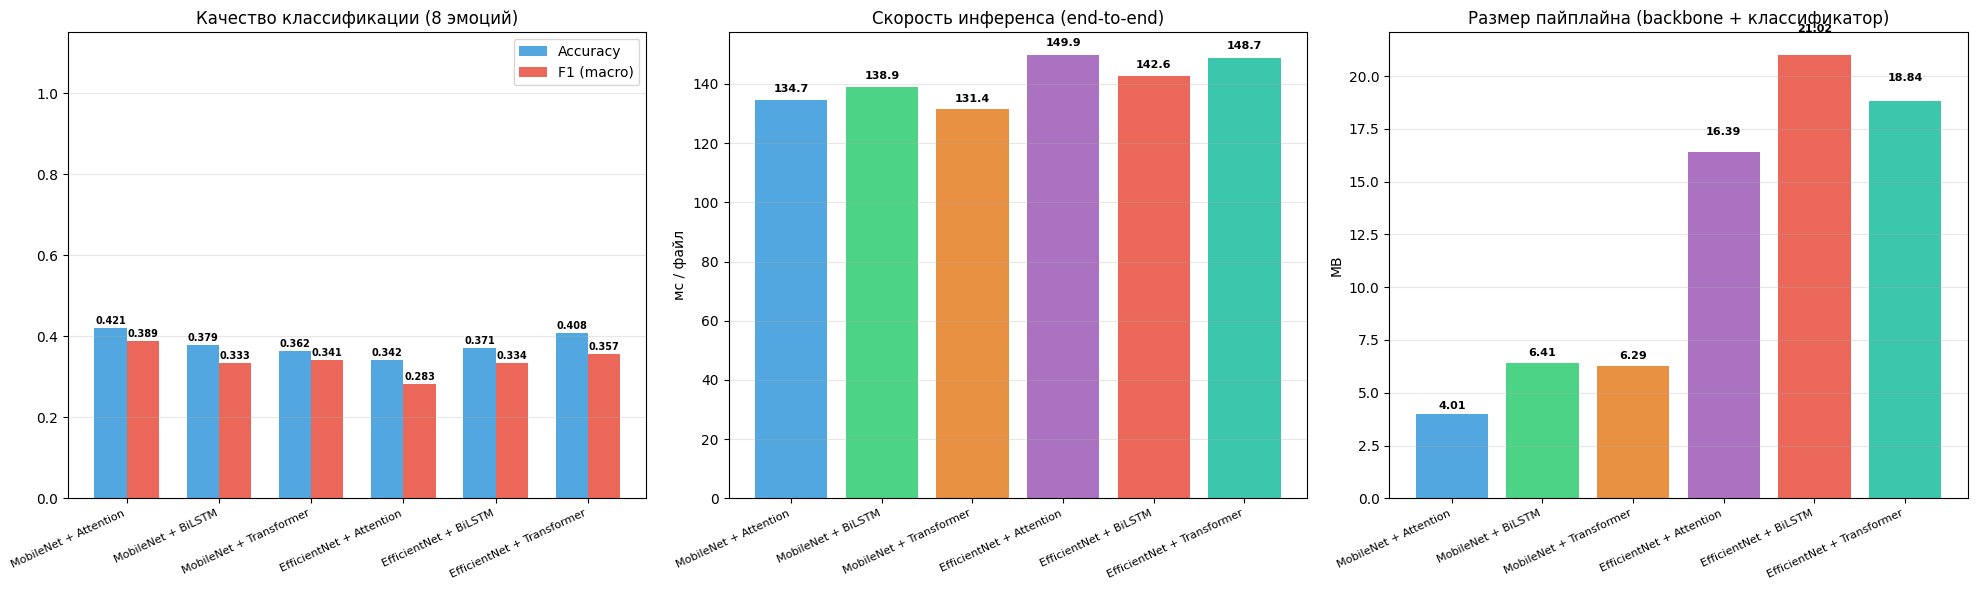

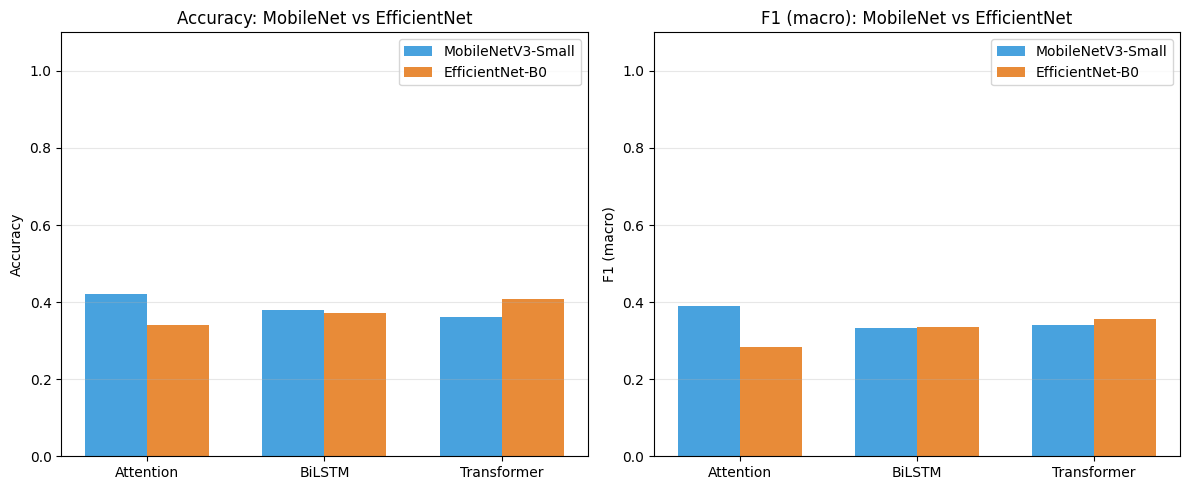

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
model_names = df["Модель"].tolist()
x = np.arange(len(model_names))
colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#e74c3c", "#1abc9c"]

# ── Качество ──
w = 0.35
b1 = axes[0].bar(x - w / 2, df["Accuracy"], w,
                  label="Accuracy", color="#3498db", alpha=0.85)
b2 = axes[0].bar(x + w / 2, df["F1 (macro)"], w,
                  label="F1 (macro)", color="#e74c3c", alpha=0.85)
axes[0].set_ylim(0, 1.15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=8, rotation=25, ha="right")
axes[0].set_title("Качество классификации (8 эмоций)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
for b in list(b1) + list(b2):
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                 f"{b.get_height():.3f}", ha="center", fontsize=7, fontweight="bold")

# ── Скорость инференса ──
b3 = axes[1].bar(x, df["Инференс (мс/файл)"], color=colors, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, fontsize=8, rotation=25, ha="right")
axes[1].set_ylabel("мс / файл")
axes[1].set_title("Скорость инференса (end-to-end)")
axes[1].grid(axis="y", alpha=0.3)
for b in b3:
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() * 1.02,
                 f"{b.get_height():.1f}", ha="center", fontsize=8, fontweight="bold")

# ── Размер пайплайна ──
b4 = axes[2].bar(x, df["Пайплайн (MB)"], color=colors, alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(model_names, fontsize=8, rotation=25, ha="right")
axes[2].set_ylabel("MB")
axes[2].set_title("Размер пайплайна (backbone + классификатор)")
axes[2].grid(axis="y", alpha=0.3)
for b in b4:
    axes[2].text(b.get_x() + b.get_width() / 2, b.get_height() * 1.05,
                 f"{b.get_height():.2f}", ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

# Попарное сравнение backbone при одинаковой темпоральной агрегации (порядок строк в df: MN×3, затем Eff×3)
fig2, axes_cmp = plt.subplots(1, 2, figsize=(12, 5))
agg_short = ["Attention", "BiLSTM", "Transformer"]
x2 = np.arange(3)
w2 = 0.35
mn_sl, ef_sl = slice(0, 3), slice(3, 6)
axes_cmp[0].bar(x2 - w2 / 2, df.iloc[mn_sl]["Accuracy"], w2, label="MobileNetV3-Small", color="#3498db", alpha=0.9)
axes_cmp[0].bar(x2 + w2 / 2, df.iloc[ef_sl]["Accuracy"], w2, label="EfficientNet-B0", color="#e67e22", alpha=0.9)
axes_cmp[0].set_xticks(x2)
axes_cmp[0].set_xticklabels(agg_short)
axes_cmp[0].set_ylim(0, 1.1)
axes_cmp[0].set_ylabel("Accuracy")
axes_cmp[0].set_title("Accuracy: MobileNet vs EfficientNet")
axes_cmp[0].legend()
axes_cmp[0].grid(axis="y", alpha=0.3)

axes_cmp[1].bar(x2 - w2 / 2, df.iloc[mn_sl]["F1 (macro)"], w2, label="MobileNetV3-Small", color="#3498db", alpha=0.9)
axes_cmp[1].bar(x2 + w2 / 2, df.iloc[ef_sl]["F1 (macro)"], w2, label="EfficientNet-B0", color="#e67e22", alpha=0.9)
axes_cmp[1].set_xticks(x2)
axes_cmp[1].set_xticklabels(agg_short)
axes_cmp[1].set_ylim(0, 1.1)
axes_cmp[1].set_ylabel("F1 (macro)")
axes_cmp[1].set_title("F1 (macro): MobileNet vs EfficientNet")
axes_cmp[1].legend()
axes_cmp[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()